In [1]:
from pathlib import Path

import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

bucket_name = "dsan6000-zw520"
s3 = boto3.client("s3")

In [2]:
response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix="wikipedia-hourly/"
)

keys = sorted(
    item["Key"]
    for item in response["Contents"]
    if item["Key"].endswith(".parquet")
)

frames = []

for key in keys:
    uri = f"s3://{bucket_name}/{key}"
    hour_df = pd.read_parquet(uri)

    hour_df["hour"] = pd.to_datetime(
        Path(key).stem,
        format="%Y%m%d_%H%M%S"
    )

    frames.append(hour_df)

df = pd.concat(frames, ignore_index=True)

In [3]:
print("num_files", len(keys))
print("rows_col", df.shape)
print("col_name：", df.columns.tolist())

df.head()

num_files 24
rows_col (119708, 30)
col_name： ['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title', 'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url', 'minor', 'length', 'revision', 'server_url', 'server_name', 'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type', 'log_action', 'log_params', 'log_action_comment', 'patrolled', 'file_ts', 'file_ts_str', 'hour']


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str,hour
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00


In [4]:
hourly_counts = (
    df.groupby("hour")
    .size()
    .reset_index(name="num_events")
)

hourly_type_counts = (
    df.groupby(["hour", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .melt(
        id_vars="hour",
        var_name="type",
        value_name="num_events"
    )
)

Path("images").mkdir(exist_ok=True)

In [5]:
len(keys), len(hourly_counts)

(24, 24)

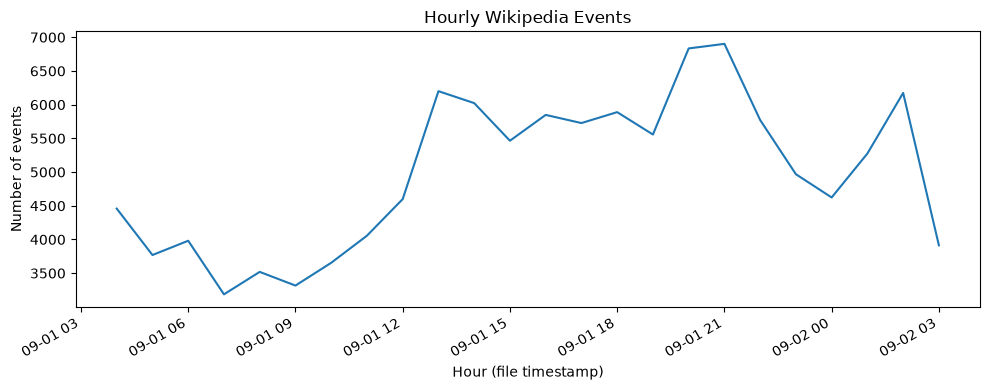

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="num_events",
    ax=ax
)

ax.set(
    title="Hourly Wikipedia Events",
    xlabel="Hour (file timestamp)",
    ylabel="Number of events"
)

fig.autofmt_xdate()
fig.tight_layout()

fig.savefig("images/hourly-events.png")
fig.savefig("images/hourly-events.svg")

plt.show()

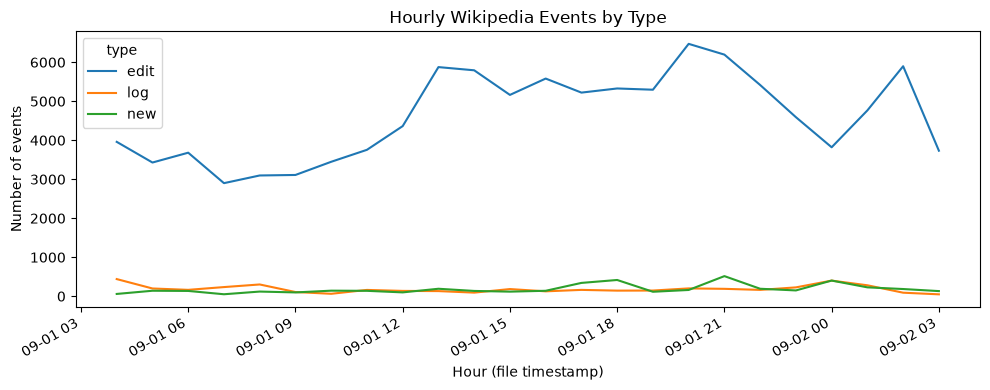

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data=hourly_type_counts,
    x="hour",
    y="num_events",
    hue="type",
    ax=ax
)

ax.set(
    title="Hourly Wikipedia Events by Type",
    xlabel="Hour (file timestamp)",
    ylabel="Number of events"
)

fig.autofmt_xdate()
fig.tight_layout()

fig.savefig("images/events-by-type.png")
fig.savefig("images/events-by-type.svg")

plt.show()